<a href="https://colab.research.google.com/github/Keistkmiya/Tugas1-MachineLearning/blob/main/Tugas1_Chapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chapter 3: Unsupervised Learning & Preprocessing




##Setup & Library Imports

In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

%matplotlib inline

## Preprocessing and Scaling

Algoritma seperti SVM atau Neural Networks sensitif dengan rentang angka. Jika
ada fitur yang skalanya ribuan dan ada yang cuma 0,1, modelnya bisa bingung. Scaling gunanya buat menyamakan "level" semua fitur.

Visualisasi Jenis-Jenis Scaling

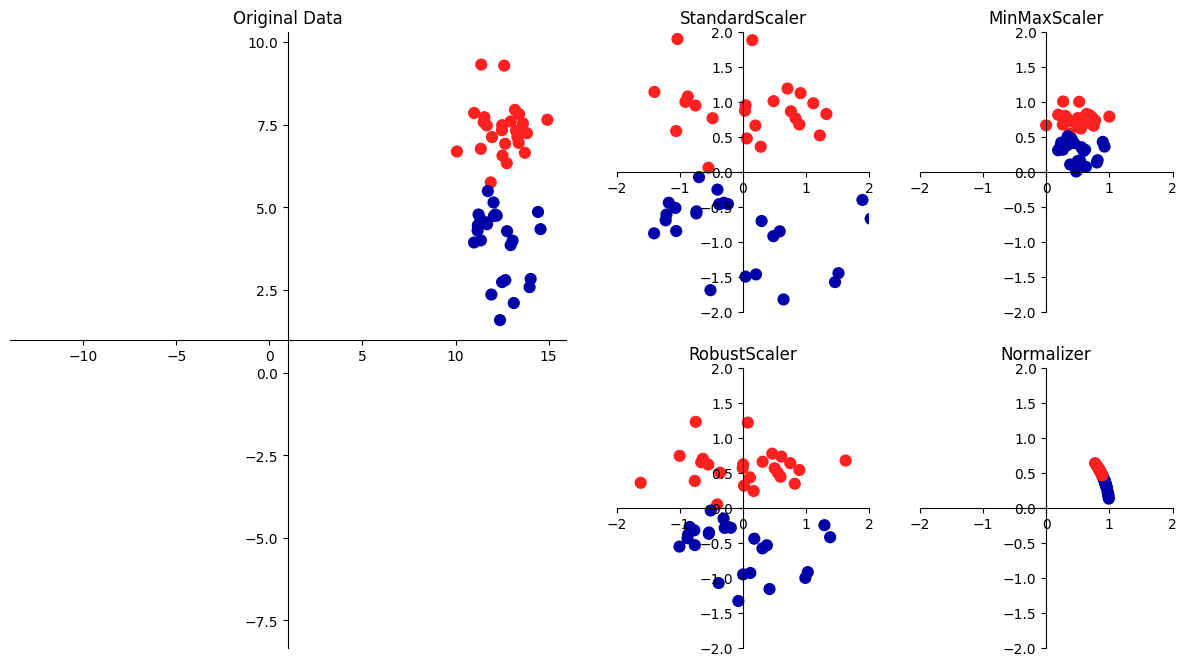

In [3]:
mglearn.plots.plot_scaling()

### Applying MinMaxScaler

In [4]:
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=1)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
print("Bentuk data setelah di-scale: {}".format(X_train_scaled.shape))
print("Nilai minimum tiap fitur: {}".format(X_train_scaled.min(axis=0)))
print("Nilai maksimum tiap fitur: {}".format(X_train_scaled.max(axis=0)))

Bentuk data setelah di-scale: (426, 30)
Nilai minimum tiap fitur: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Nilai maksimum tiap fitur: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


### Scaling the Test Set Correctly

In [5]:
X_test_scaled = scaler.transform(X_test)

print("Nilai minimum data test setelah di-scale: {}".format(X_test_scaled.min(axis=0)))
print("Nilai maksimum data test setelah di-scale: {}".format(X_test_scaled.max(axis=0)))

Nilai minimum data test setelah di-scale: [ 0.0336031   0.0226581   0.03144219  0.01141039  0.14128374  0.04406704
  0.          0.          0.1540404  -0.00615249 -0.00137796  0.00594501
  0.00430665  0.00079567  0.03919502  0.0112206   0.          0.
 -0.03191387  0.00664013  0.02660975  0.05810235  0.02031974  0.00943767
  0.1094235   0.02637792  0.          0.         -0.00023764 -0.00182032]
Nilai maksimum data test setelah di-scale: [0.9578778  0.81501522 0.95577362 0.89353128 0.81132075 1.21958701
 0.87956888 0.9333996  0.93232323 1.0371347  0.42669616 0.49765736
 0.44117231 0.28371044 0.48703131 0.73863671 0.76717172 0.62928585
 1.33685792 0.39057253 0.89612238 0.79317697 0.84859804 0.74488793
 0.9154725  1.13188961 1.07008547 0.92371134 1.20532319 1.63068851]


## The Effect of Preprocessing on Supervised Learning

Kita akan menggunakan algoritma SVC (Support Vector Classifier). Algoritma ini terkenal sangat tidak mudah soal skala data. Kita akan bandingkan skornya saat pakai data asli vs data yang sudah di-scale.

SVC pada Data Asli

In [6]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)

print("Accuracy on training set: {:.3f}".format(svc.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(svc.score(X_test, y_test)))

Accuracy on training set: 0.925
Accuracy on test set: 0.909


SVC pada Data yang Sudah Di-scale (MinMaxScaler)

In [7]:
svc.fit(X_train_scaled, y_train)

print("Scaled training set accuracy: {:.3f}".format(svc.score(X_train_scaled, y_train)))
print("Scaled test set accuracy: {:.3f}".format(svc.score(X_test_scaled, y_test)))

Scaled training set accuracy: 0.986
Scaled test set accuracy: 0.965


## Dimensionality Reduction (Principal Component Analysis)

Dataset kanker yang kita pakai punya 30 fitur (dimensi). Manusia tidak mungkin bisa membayangkan atau menggambar grafik 30D. PCA (Principal Component Analysis) bakal mencari pola paling penting dan "memeras" 30 fitur itu jadi cuma 2 fitur utama tanpa buang terlalu banyak informasi. Tujuannya? Biar kita bisa ngelihat persebaran datanya di grafik 2D biasa.

Implementasi PCA

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_train_scaled)

print("Original shape: {}".format(str(X_train_scaled.shape)))
print("Reduced shape: {}".format(str(X_pca.shape)))

Original shape: (426, 30)
Reduced shape: (426, 2)


### Visualizing the Principal Components

Text(0, 0.5, 'Second principal component')

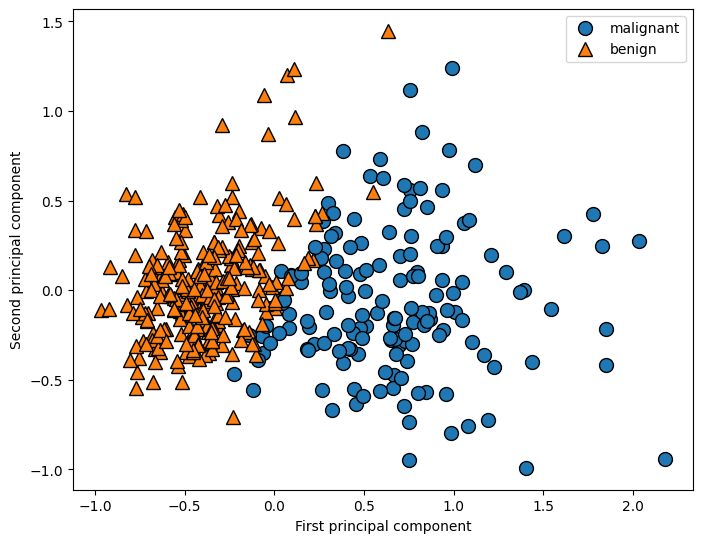

In [10]:
plt.figure(figsize=(8, 8))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], y_train)
plt.legend(cancer.target_names, loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

### Inspecting the Components (The Heatmap)

Text(0, 0.5, 'Principal components')

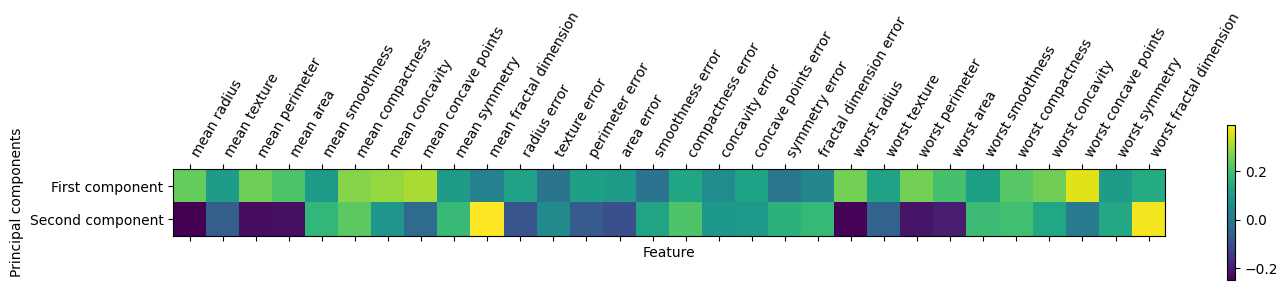

In [11]:
plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
           cancer.feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components")

### Manifold Learning with t-SNE

t-SNE (t-distributed Stochastic Neighbor Embedding) adalah algoritma visualisasi yang sangat kuat. Berbeda dengan PCA, t-SNE mencoba menjaga agar poin yang berdekatan di dimensi tinggi tetap berdekatan di dimensi rendah.

### Visualizing the Digits Dataset

Text(0, 0.5, 't-SNE feature 1')

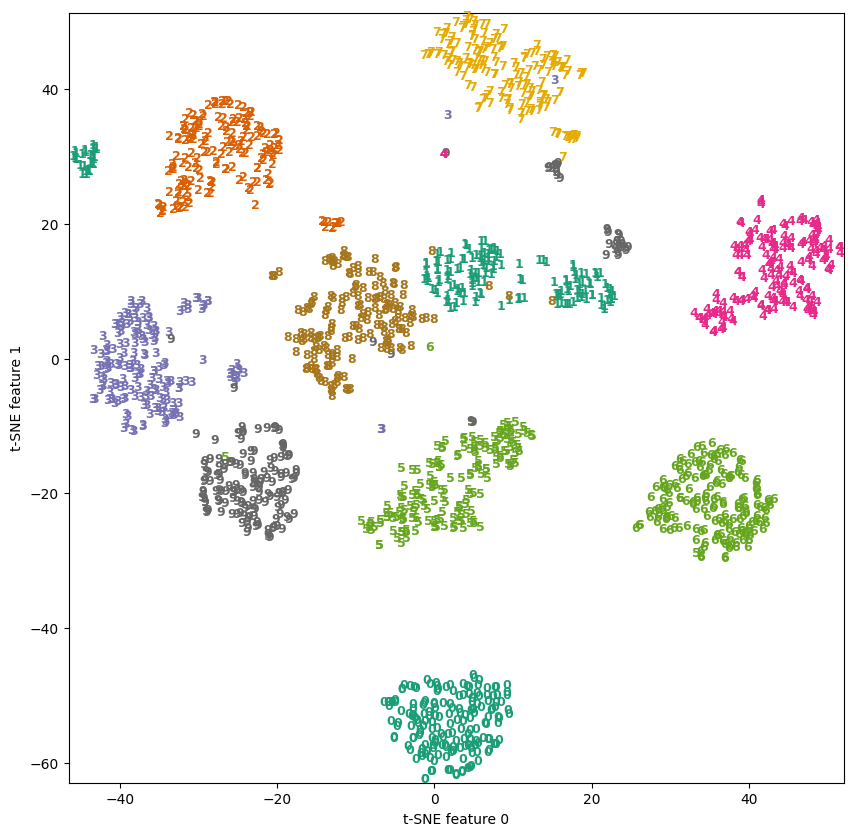

In [12]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

digits = load_digits()
tsne = TSNE(random_state=42)
digits_tsne = tsne.fit_transform(digits.data)

plt.figure(figsize=(10, 10))
plt.xlim(digits_tsne[:, 0].min(), digits_tsne[:, 0].max() + 1)
plt.ylim(digits_tsne[:, 1].min(), digits_tsne[:, 1].max() + 1)

for i in range(len(digits.data)):
    plt.text(digits_tsne[i, 0], digits_tsne[i, 1], str(digits.target[i]),
             color = plt.cm.Dark2(digits.target[i] / 10.),
             fontdict={'weight': 'bold', 'size': 9})

plt.xlabel("t-SNE feature 0")
plt.ylabel("t-SNE feature 1")

## Clustering

Clustering adalah tugas mengelompokkan set objek sedemikian rupa sehingga objek dalam kelompok yang sama (cluster) lebih mirip satu sama lain daripada objek di kelompok lain. Kita akan bahas tiga algoritma utama: k-Means, Agglomerative Clustering, dan DBSCAN.

### k-Means Clustering

In [13]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(random_state=1)
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

print("Cluster assignments:\n{}".format(kmeans.labels_))

Cluster assignments:
[1 0 0 0 2 2 2 0 1 1 0 0 2 1 2 2 2 1 0 0 2 0 2 1 0 2 2 1 1 2 1 1 2 1 0 2 0
 0 0 2 2 0 1 0 0 2 1 1 1 1 0 2 2 2 1 2 0 0 1 1 0 2 2 0 0 2 1 2 1 0 0 0 2 1
 1 0 2 2 1 0 1 0 0 2 1 1 1 1 0 1 2 1 1 0 0 2 2 1 2 1]


### Visualizing k-Means

Text(0, 0.5, 'Feature 1')

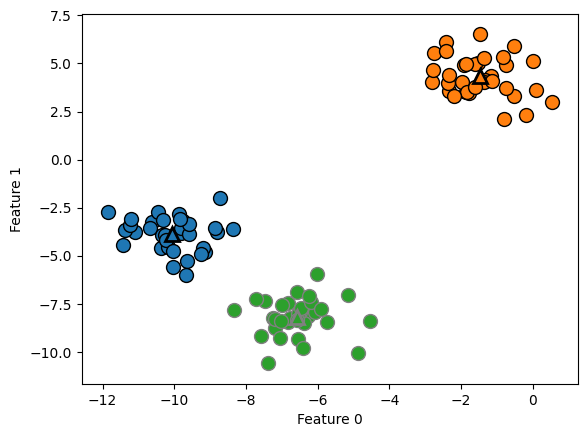

In [14]:
mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
    markers='^', markeredgewidth=2)

plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

### When k-Means Fails

Text(0, 0.5, 'Feature 1')

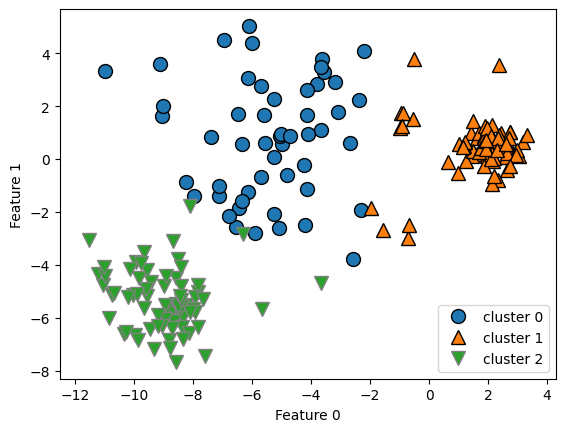

In [15]:
X_varied, y_varied = make_blobs(n_samples=200, cluster_std=[1.0, 2.5, 0.5], random_state=170)
y_pred = KMeans(n_clusters=3, random_state=0).fit_predict(X_varied)

mglearn.discrete_scatter(X_varied[:, 0], X_varied[:, 1], y_pred)
plt.legend(["cluster 0", "cluster 1", "cluster 2"], loc='best')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

### Agglomerative Clustering

Agglomerative Clustering bekerja secara "bottom-up". Bayangkan setiap titik data adalah satu kelompok kecil sendirian. Algoritma ini akan menggabungkan dua kelompok yang paling mirip, terus berulang sampai akhirnya tersisa jumlah kelompok yang kita inginkan.

Text(0, 0.5, 'Feature 1')

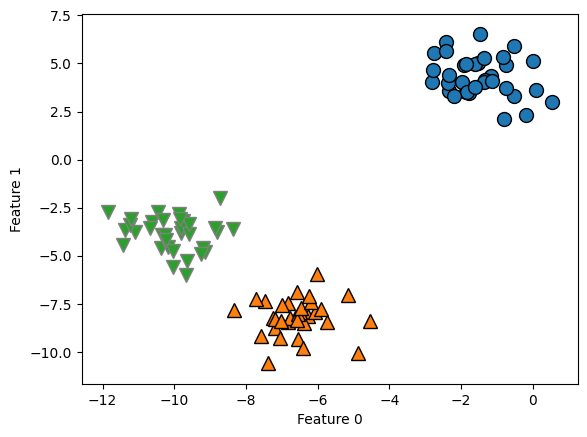

In [16]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X)
mglearn.discrete_scatter(X[:, 0], X[:, 1], assignment)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

### Dendrograms (Hierarchical Visualization)

Text(0, 0.5, 'Cluster distance')

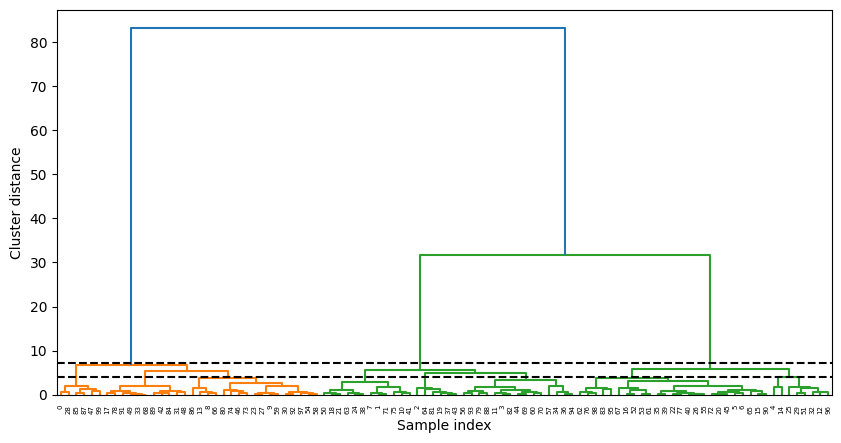

In [17]:
from scipy.cluster.hierarchy import dendrogram, ward

linkage_array = ward(X)
plt.figure(figsize=(10, 5))
dendrogram(linkage_array)
ax = plt.gca()
bounds = ax.get_xbound()
ax.plot(bounds, [7.25, 7.25], '--', c='k')
ax.plot(bounds, [4, 4], '--', c='k')

plt.xlabel("Sample index")
plt.ylabel("Cluster distance")

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN beda dengan k-Means atau Agglomerative karena dia tidak meminta kita untuk tentukan jumlah cluster dari awal. Dia bekerja berdasarkan kepadatan data.

Cluster assignments:
[0 1 1 1 2 2 2 1 0 0 1 1 2 0 2 2 2 0 1 1 2 1 2 0 1 2 2 0 0 2 0 0 2 0 1 2 1
 1 1 2 2 1 0 1 1 2 0 0 0 0 1 2 2 2 0 2 1 1 0 0 1 2 2 1 1 2 0 2 0 1 1 1 2 0
 0 1 2 2 0 1 0 1 1 2 0 0 0 0 1 0 2 0 0 1 1 2 2 0 2 0]


Text(0, 0.5, 'Feature 1')

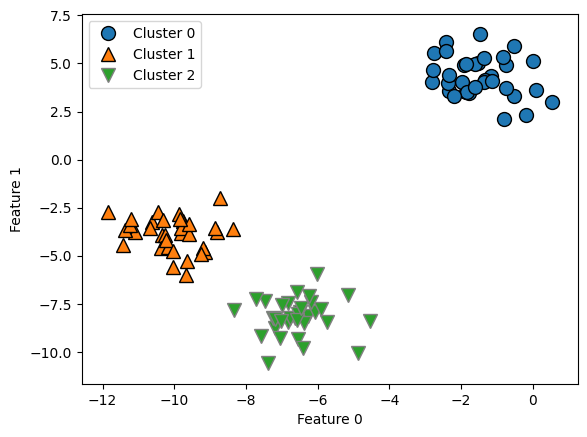

In [18]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=3)
clusters = dbscan.fit_predict(X)
print("Cluster assignments:\n{}".format(clusters))

mglearn.discrete_scatter(X[:, 0], X[:, 1], clusters)
plt.legend(["Cluster 0", "Cluster 1", "Cluster 2", "Noise"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

### Comparing k-Means and DBSCAN on Complex Geometry

Kita akan menggunakan dataset make_moons, yaitu dataset buatan yang bentuknya seperti dua bulan sabit yang saling berhimpitan. Di sini kamu akan melihat perbedaan mencolok: k-Means akan memotong bulan sabit tersebut menjadi beberapa bagian, sedangkan DBSCAN bisa mengenali bentuk bulan sabit itu secara utuh sebagai satu kesatuan.

Text(0, 0.5, 'Feature 1')

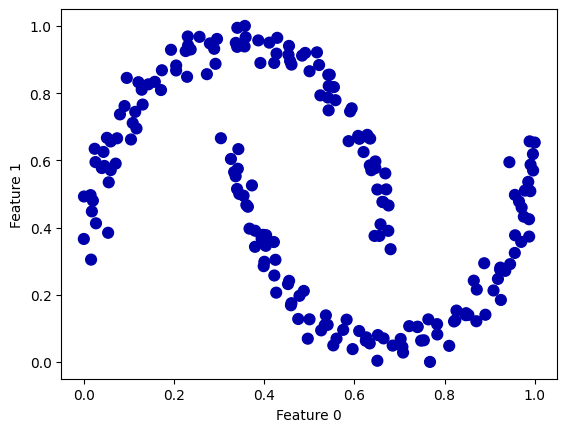

In [19]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)
scaler = MinMaxScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
dbscan = DBSCAN(eps=0.2)
clusters = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap=mglearn.cm2, s=60)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

## Comparing and Evaluating Clustering Algorithms

Skor ARI berkisar dari 0 sampai 1.


1.   1.0: Pengelompokan sempurna (sama persis dengan label asli).
2.   0.0: Pengelompokan acak/berantakan.

Kita akan adu ketiga algoritma tadi (k-Means, Agglomerative, dan DBSCAN) untuk melihat siapa pemenangnya di dataset bulan sabit.



### Evaluation with Adjusted Rand Index (ARI)

In [20]:
from sklearn.metrics.cluster import adjusted_rand_score

kmeans = KMeans(n_clusters=2)
kmeans_clusters = kmeans.fit_predict(X_scaled)
agg = AgglomerativeClustering(n_clusters=2)
agg_clusters = agg.fit_predict(X_scaled)
dbscan = DBSCAN(eps=0.2)
dbscan_clusters = dbscan.fit_predict(X_scaled)

print("k-Means ARI: {:.2f}".format(adjusted_rand_score(y, kmeans_clusters)))
print("Agglomerative ARI: {:.2f}".format(adjusted_rand_score(y, agg_clusters)))
print("DBSCAN ARI: {:.2f}".format(adjusted_rand_score(y, dbscan_clusters)))

k-Means ARI: 0.52
Agglomerative ARI: 0.61
DBSCAN ARI: 0.00
